In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, NullLocator


CANDIDATE_BASE_DIRS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd() / "presentation" / "classifier",
    Path.cwd().parent / "presentation" / "classifier",
]

BASE_DIR = next(
    (path.resolve() for path in CANDIDATE_BASE_DIRS if (path / "model_comparison.csv").exists()),
    None,
)
if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find model_comparison.csv. Start the notebook from presentation/classifier "
        "or its notebooks directory."
    )

CSV_PATH = BASE_DIR / "model_comparison.csv"
# v2 = final plots for the presentation. v1 holds the previous iteration.
PLOT_DIR = BASE_DIR / "plots" / "model_comparison" / "v2"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df["model"] = df["model"].astype(str)

print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Writing plots to {PLOT_DIR}")


Loaded 7 rows from /Users/lukas.amiet/Documents/CODE/MLonMCU_proj/presentation/classifier/model_comparison.csv
Writing plots to /Users/lukas.amiet/Documents/CODE/MLonMCU_proj/presentation/classifier/plots/model_comparison/v2


In [2]:
EXPORT_DPI = 300
FIG_BG = "white"
EDGE_COLOR = "#2F3437"
GRID_COLOR = "#D8DDE3"
TEXT_COLOR = "#202326"
MUTED_TEXT_COLOR = "#565E66"

FAMILY_COLORS = {
    "smallnet": "#4C78A8",
    "bignet": "#D9903D",
    "bignet_pruned": "#59A14F",
    "unknown": "#8A8F98",
}
RAM_COLOR = "#5F6B7A"
FLASH_COLOR = "#B07AA1"
CONSTRAINT_COLOR = "#D62728"  # red - hard hardware limits

# STM32U5 hard resource budget (the target MCU).
RAM_LIMIT_KB = 786       # 786 KB SRAM
FLASH_LIMIT_KB = 2048    # 2 MB flash
LATENCY_COLORS = {
    "Preprocessing": "#6B7280",
    "Inference": "#4C78A8",
    "Postprocessing": "#B07AA1",
}

plt.rcParams.update(
    {
        "figure.facecolor": FIG_BG,
        "axes.facecolor": FIG_BG,
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.titleweight": "semibold",
        "axes.labelsize": 9,
        "axes.labelcolor": TEXT_COLOR,
        "axes.edgecolor": EDGE_COLOR,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "grid.color": GRID_COLOR,
        "grid.linewidth": 0.7,
        "grid.alpha": 0.75,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "figure.dpi": 140,
        "savefig.dpi": EXPORT_DPI,
        "savefig.facecolor": FIG_BG,
        "savefig.edgecolor": FIG_BG,
    }
)


def save_figure(fig, name):
    for ext in ("png", "pdf", "svg"):
        path = PLOT_DIR / f"{name}.{ext}"
        kwargs = {"bbox_inches": "tight", "facecolor": fig.get_facecolor()}
        if ext == "png":
            kwargs["dpi"] = EXPORT_DPI
        fig.savefig(path, **kwargs)


def apply_common_axis_style(ax):
    ax.set_facecolor(FIG_BG)
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="y", color=GRID_COLOR, linewidth=0.7, alpha=0.75)
    ax.grid(False, which="minor", axis="both")

    for spine_name in ("top", "right"):
        ax.spines[spine_name].set_visible(False)
    for spine_name in ("left", "bottom"):
        ax.spines[spine_name].set_color(EDGE_COLOR)
        ax.spines[spine_name].set_linewidth(0.8)

    ax.tick_params(axis="both", which="major", length=3.5, width=0.7, color=EDGE_COLOR)


def style_legend(legend):
    if legend is None:
        return None
    frame = legend.get_frame()
    frame.set_visible(True)
    frame.set_alpha(0.95)
    frame.set_linewidth(0.8)
    frame.set_facecolor("#FFFFFF")
    frame.set_edgecolor("#C9CED6")
    return legend


def nice_upper_limit(values):
    series = pd.to_numeric(pd.Series(values), errors="coerce").dropna()
    if series.empty or series.max() <= 0:
        return 1.0

    max_value = float(series.max()) * 1.08
    exponent = np.floor(np.log10(max_value))
    base = 10**exponent
    fraction = max_value / base

    for nice_fraction in (1.0, 2.0, 2.5, 5.0, 10.0):
        if fraction <= nice_fraction:
            return nice_fraction * base
    return 10.0 * base


def scale_marker_sizes(values, min_size=70, max_size=420):
    series = pd.to_numeric(pd.Series(values), errors="coerce")
    if series.empty:
        return np.array([])

    valid = series.dropna()
    midpoint = (min_size + max_size) / 2
    if valid.empty or valid.max() == valid.min():
        return np.full(len(series), midpoint)

    normalized = (series - valid.min()) / (valid.max() - valid.min())
    normalized = normalized.fillna(0.5).to_numpy()
    return min_size + normalized * (max_size - min_size)


def annotate_points(ax, data, x_col, y_col):
    offsets = [(5, 6), (5, -10), (-5, 6), (-5, -10), (8, 0), (-8, 0)]
    for idx, (_, row) in enumerate(data.reset_index(drop=True).iterrows()):
        x_value = row[x_col]
        y_value = row[y_col]
        if pd.isna(x_value) or pd.isna(y_value):
            continue

        dx, dy = offsets[idx % len(offsets)]
        ha = "left" if dx >= 0 else "right"
        ax.annotate(
            str(row["display_model"]),
            xy=(x_value, y_value),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=7,
            color=TEXT_COLOR,
        )


def add_value_labels(ax, bars, fmt="{:.3f}", padding=3, fontsize=7, rotation=0):
    is_log_axis = ax.get_yscale() == "log"
    for bar in bars:
        height = bar.get_height()
        if not np.isfinite(height) or (is_log_axis and height <= 0):
            continue

        label = fmt(height) if callable(fmt) else fmt.format(height)
        x_value = bar.get_x() + bar.get_width() / 2
        if is_log_axis:
            ax.text(
                x_value,
                height * 1.08,
                label,
                ha="center",
                va="bottom",
                fontsize=fontsize,
                rotation=rotation,
                color=TEXT_COLOR,
            )
        else:
            ax.annotate(
                label,
                xy=(x_value, height),
                xytext=(0, padding),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=fontsize,
                rotation=rotation,
                color=TEXT_COLOR,
            )


def family_legend(ax, data, loc="best"):
    families = [family for family in family_order if family in set(data["family"].dropna())]
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            label=FAMILY_DISPLAY.get(family, family),
            markerfacecolor=FAMILY_COLORS.get(family, FAMILY_COLORS["unknown"]),
            markeredgecolor=EDGE_COLOR,
            markeredgewidth=0.7,
            markersize=7,
        )
        for family in families
    ]
    if not handles:
        return None
    return style_legend(ax.legend(handles=handles, title="Family", loc=loc, frameon=True))


def bubble_note(ax, note):
    ax.text(
        0.98,
        0.04,
        note,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color=MUTED_TEXT_COLOR,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "#FFFFFF",
            "edgecolor": "#D0D5DD",
            "linewidth": 0.7,
            "alpha": 0.92,
        },
    )


In [3]:
family_order = ["smallnet", "bignet", "bignet_pruned"]
variant_order = ["fp32", "int8", "int8_cmsisnn"]

FAMILY_DISPLAY = {
    "smallnet": "SmallNet",
    "bignet": "BigNet",
    "bignet_pruned": "BigNet pruned",
    "unknown": "Unknown",
}
# Base name (line 1 of the horizontal axis label) and whether the family is pruned.
FAMILY_BASE_DISPLAY = {
    "smallnet": "SmallNet",
    "bignet": "BigNet",
    "bignet_pruned": "BigNet",
    "unknown": "Unknown",
}
PRUNED_FAMILIES = {"bignet_pruned"}
VARIANT_DISPLAY = {
    "fp32": "FP32",
    "int8": "INT8",
    "int8_cmsisnn": "INT8 CMSIS-NN",
    "unknown": "Unknown",
}
# Axis form may use a line break to keep the column label narrow.
VARIANT_AXIS = {
    "fp32": "FP32",
    "int8": "INT8",
    "int8_cmsisnn": "INT8\nCMSIS-NN",
}
VARIANT_HATCHES = {
    "fp32": "",
    "int8": "///",
    "int8_cmsisnn": "..",
}


def parse_family(model):
    model = str(model)
    for family in sorted(family_order, key=len, reverse=True):
        if model == family or model.startswith(f"{family}_"):
            return family
    return "unknown"


def parse_variant(model, family):
    model = str(model)
    if family == "unknown":
        return "unknown"

    prefix = f"{family}_"
    remainder = model[len(prefix) :] if model.startswith(prefix) else model
    for variant in sorted(variant_order, key=len, reverse=True):
        if remainder == variant:
            return variant
    return remainder if remainder else "unknown"


def make_axis_label(family, variant):
    """Horizontal x-axis label: family on line 1, '(pruned) <precision>' below it."""
    base = FAMILY_BASE_DISPLAY.get(family, family)
    precision = VARIANT_AXIS.get(variant, VARIANT_DISPLAY.get(variant, str(variant).upper()))
    prefix = "(pruned) " if family in PRUNED_FAMILIES else ""
    return f"{base}\n{prefix}{precision}"


df["family"] = df["model"].apply(parse_family)
df["variant"] = [parse_variant(model, family) for model, family in zip(df["model"], df["family"])]
df["family_display"] = df["family"].map(FAMILY_DISPLAY).fillna(df["family"])
df["variant_display"] = df["variant"].map(VARIANT_DISPLAY).fillna(df["variant"].str.upper())
df["display_model"] = (df["family_display"] + " " + df["variant_display"]).str.strip()
df["axis_label"] = [make_axis_label(family, variant) for family, variant in zip(df["family"], df["variant"])]

family_rank = df["family"].map({family: idx for idx, family in enumerate(family_order)}).fillna(len(family_order))
variant_rank = df["variant"].map({variant: idx for idx, variant in enumerate(variant_order)}).fillna(len(variant_order))
df = (
    df.assign(family_rank=family_rank, variant_rank=variant_rank)
    .sort_values(["family_rank", "variant_rank", "model"])
    .drop(columns=["family_rank", "variant_rank"])
    .reset_index(drop=True)
)


def make_variant_handles(variants):
    return [
        Patch(
            facecolor="#FFFFFF",
            edgecolor=EDGE_COLOR,
            hatch=VARIANT_HATCHES.get(variant, ""),
            linewidth=0.8,
            label=VARIANT_DISPLAY.get(variant, variant),
        )
        for variant in variants
    ]


def grouped_family_variant_plot(ax, metric, title, ylabel):
    plot_data = df.dropna(subset=[metric]).copy()
    available_families = [family for family in family_order if family in set(plot_data["family"])]
    available_variants = [variant for variant in variant_order if variant in set(plot_data["variant"])]

    apply_common_axis_style(ax)
    ax.set_title(title, pad=8)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.08)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

    if not available_families or not available_variants:
        ax.text(0.5, 0.5, f"No data for {metric}", transform=ax.transAxes, ha="center", va="center")
        return

    x_positions = np.arange(len(available_families), dtype=float)
    width = min(0.22, 0.72 / max(len(available_variants), 1))

    for variant_idx, variant in enumerate(available_variants):
        offset = (variant_idx - (len(available_variants) - 1) / 2) * width * 1.18
        for family_idx, family in enumerate(available_families):
            rows = plot_data[(plot_data["family"] == family) & (plot_data["variant"] == variant)]
            if rows.empty:
                continue

            value = float(rows.iloc[0][metric])
            bars = ax.bar(
                x_positions[family_idx] + offset,
                value,
                width=width,
                color=FAMILY_COLORS.get(family, FAMILY_COLORS["unknown"]),
                edgecolor=EDGE_COLOR,
                linewidth=0.7,
                hatch=VARIANT_HATCHES.get(variant, ""),
                alpha=0.88,
            )
            add_value_labels(ax, bars, fmt="{:.3f}", padding=2, fontsize=6.5)

    ax.set_xticks(x_positions)
    ax.set_xticklabels([FAMILY_DISPLAY.get(family, family) for family in available_families])
    legend = ax.legend(
        handles=make_variant_handles(available_variants),
        title="Variant",
        loc="upper left",
        frameon=True,
        ncol=min(len(available_variants), 3),
    )
    style_legend(legend)


In [4]:
summary_columns = [
    "model",
    "family",
    "variant",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "pre_ms_mean",
    "infer_ms_mean",
    "post_ms_mean",
    "flash_KB",
    "ram_KB",
    "params",
    "macc",
    "energy_mJ",
]

summary = df[[column for column in summary_columns if column in df.columns]].copy()
summary


,model,family,variant,accuracy,macro_precision,macro_recall,macro_f1,pre_ms_mean,infer_ms_mean,post_ms_mean,flash_KB,ram_KB,params,macc,energy_mJ
0,smallnet_fp32,smallnet,fp32,0.8232,0.8270,0.8227,0.8179,1.20,8244.90,0.007,365.0,690.5,93446,184666598,138.891
1,smallnet_int8,smallnet,int8,0.8238,0.8274,0.8221,0.8179,0.84,1677.76,0.008,92.9,179.8,93446,183668710,28.273
2,bignet_fp32,bignet,fp32,0.9710,0.9710,0.9706,0.9707,1.20,3230.21,0.007,742.9,345.0,190182,72482390,54.427
3,bignet_int8,bignet,int8,0.9720,0.9721,0.9716,0.9717,0.84,723.43,0.008,187.7,91.7,190182,71911382,12.199
4,bignet_pruned_fp32,bignet_pruned,fp32,0.9369,0.9372,0.9369,0.9369,1.20,499.18,0.007,68.0,107.4,17417,7614225,8.428
5,bignet_pruned_int8,bignet_pruned,int8,0.9357,0.9360,0.9360,0.9358,0.84,155.78,0.008,17.6,27.0,17417,7437357,2.638
6,bignet_pruned_int8_cmsisnn,bignet_pruned,int8_cmsisnn,0.9380,0.9370,0.9372,0.9370,0.96,284.87,0.008,32.0,192.0,17417,7437357,4.815


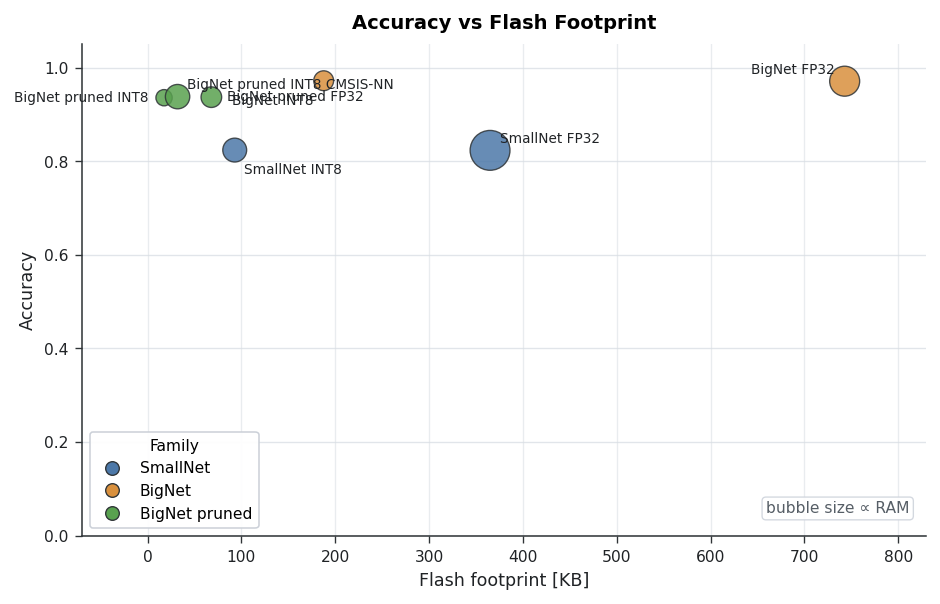

In [5]:
plot_data = df.dropna(subset=["flash_KB", "accuracy", "ram_KB"]).copy().reset_index(drop=True)
plot_data["marker_size"] = scale_marker_sizes(plot_data["ram_KB"])

fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)

for family in family_order:
    family_data = plot_data[plot_data["family"] == family]
    if family_data.empty:
        continue
    ax.scatter(
        family_data["flash_KB"],
        family_data["accuracy"],
        s=family_data["marker_size"],
        color=FAMILY_COLORS.get(family, FAMILY_COLORS["unknown"]),
        alpha=0.85,
        edgecolor=EDGE_COLOR,
        linewidth=0.7,
    )

annotate_points(ax, plot_data, "flash_KB", "accuracy")
ax.set_title("Accuracy vs Flash Footprint", pad=8)
ax.set_xlabel("Flash footprint [KB]")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.margins(x=0.12, y=0.08)

apply_common_axis_style(ax)
ax.grid(True, which="major", axis="x", color=GRID_COLOR, linewidth=0.7, alpha=0.55)
family_legend(ax, plot_data, loc="lower left")
bubble_note(ax, "bubble size ∝ RAM")

save_figure(fig, "accuracy_vs_flash_footprint")
plt.show()


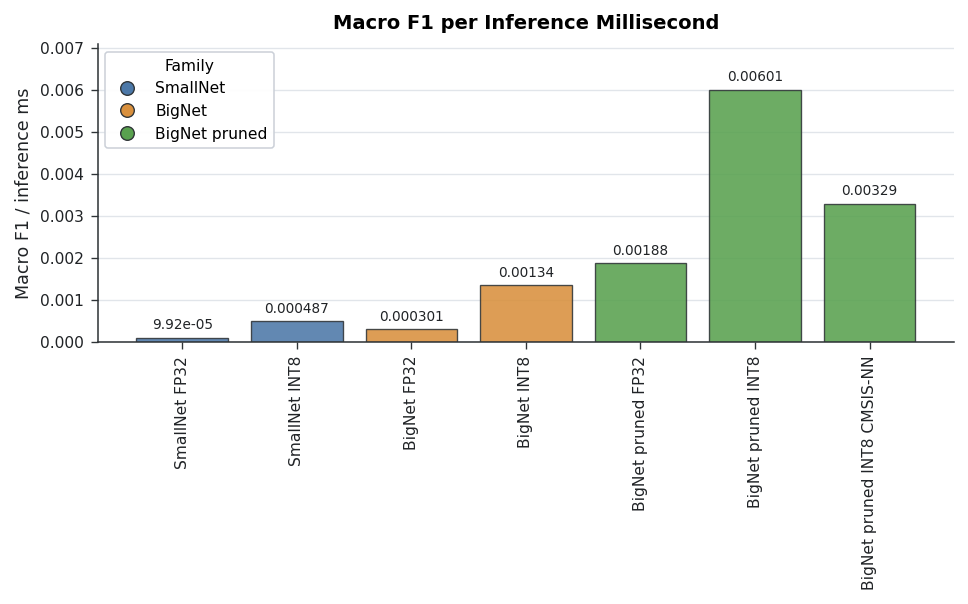

In [6]:
plot_data = df.dropna(subset=["macro_f1", "infer_ms_mean"]).copy()
plot_data = plot_data[plot_data["infer_ms_mean"] > 0].reset_index(drop=True)
plot_data["macro_f1_per_inference_ms"] = plot_data["macro_f1"] / plot_data["infer_ms_mean"]

fig, ax = plt.subplots(figsize=(6.8, 4.2), constrained_layout=True)
x_positions = np.arange(len(plot_data))
colors = [FAMILY_COLORS.get(family, FAMILY_COLORS["unknown"]) for family in plot_data["family"]]

bars = ax.bar(
    x_positions,
    plot_data["macro_f1_per_inference_ms"],
    color=colors,
    edgecolor=EDGE_COLOR,
    linewidth=0.7,
    alpha=0.88,
)

ax.set_title("Macro F1 per Inference Millisecond", pad=8)
ax.set_ylabel("Macro F1 / inference ms")
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["display_model"], rotation=90, ha="center")
if not plot_data.empty:
    ax.set_ylim(0, plot_data["macro_f1_per_inference_ms"].max() * 1.18)
add_value_labels(ax, bars, fmt=lambda value: f"{value:.3g}", padding=3, fontsize=7)

apply_common_axis_style(ax)
family_legend(ax, plot_data, loc="upper left")

save_figure(fig, "macro_f1_per_inference_ms")
plt.show()


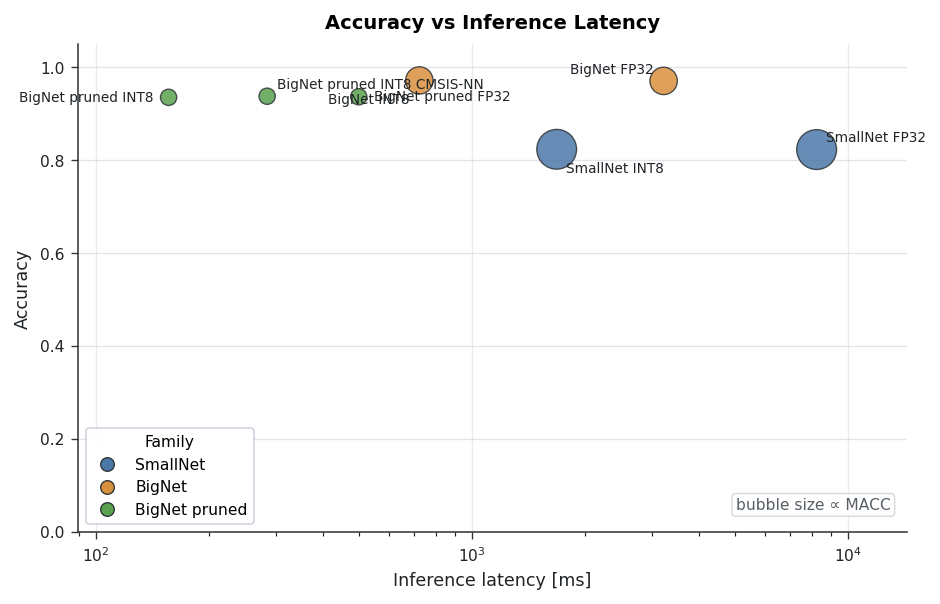

In [7]:
plot_data = df.dropna(subset=["infer_ms_mean", "accuracy", "macc"]).copy()
plot_data = plot_data[(plot_data["infer_ms_mean"] > 0) & (plot_data["macc"] > 0)].reset_index(drop=True)
plot_data["marker_size"] = scale_marker_sizes(plot_data["macc"])

fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)

for family in family_order:
    family_data = plot_data[plot_data["family"] == family]
    if family_data.empty:
        continue
    ax.scatter(
        family_data["infer_ms_mean"],
        family_data["accuracy"],
        s=family_data["marker_size"],
        color=FAMILY_COLORS.get(family, FAMILY_COLORS["unknown"]),
        alpha=0.85,
        edgecolor=EDGE_COLOR,
        linewidth=0.7,
    )

annotate_points(ax, plot_data, "infer_ms_mean", "accuracy")
ax.set_title("Accuracy vs Inference Latency", pad=8)
ax.set_xlabel("Inference latency [ms]")
ax.set_ylabel("Accuracy")
ax.set_xscale("log")
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.margins(x=0.14, y=0.08)

apply_common_axis_style(ax)
ax.grid(True, which="major", axis="x", color=GRID_COLOR, linewidth=0.7, alpha=0.55)
ax.grid(False, which="minor", axis="x")
family_legend(ax, plot_data, loc="lower left")
bubble_note(ax, "bubble size ∝ MACC")

save_figure(fig, "accuracy_vs_inference_latency")
plt.show()


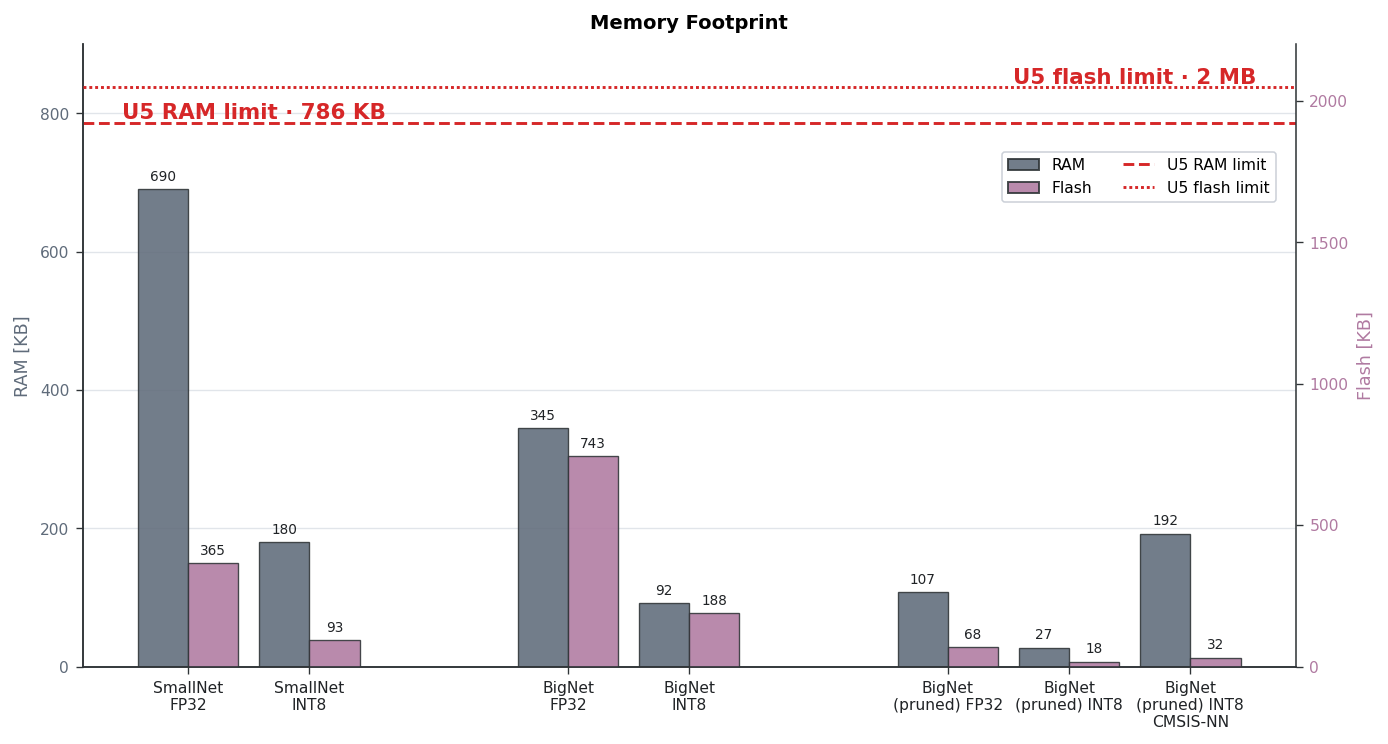

In [8]:
plot_data = df.dropna(subset=["ram_KB", "flash_KB"]).copy().reset_index(drop=True)

# Cluster the precision variants (FP32 / INT8 / CMSIS-NN) of the same family together,
# with a wider gap between families.
INTRA_STEP = 0.82   # spacing between variants of the same family
INTER_STEP = 1.75   # spacing between families
families_seq = list(plot_data["family"])
positions = []
pos = 0.0
for i, family in enumerate(families_seq):
    if i > 0:
        pos += INTRA_STEP if family == families_seq[i - 1] else INTER_STEP
    positions.append(pos)
x_positions = np.array(positions)

fig, ax = plt.subplots(figsize=(9.8, 5.2), constrained_layout=True)
ax2 = ax.twinx()
width = 0.34

ram_bars = ax.bar(
    x_positions - width / 2,
    plot_data["ram_KB"],
    width=width,
    color=RAM_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.7,
    alpha=0.88,
)
flash_bars = ax2.bar(
    x_positions + width / 2,
    plot_data["flash_KB"],
    width=width,
    color=FLASH_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.7,
    alpha=0.88,
)

# Axis limits chosen so each red U5 limit sits near the top of its own axis.
ram_max = 900.0
flash_max = 2200.0
ax.set_ylim(0, ram_max)
ax2.set_ylim(0, flash_max)
ax.set_yticks([0, 200, 400, 600, 800])
ax2.set_yticks([0, 500, 1000, 1500, 2000])

# Hard STM32U5 budget (red): RAM limit on the left axis, flash limit on the right axis.
ax.axhline(RAM_LIMIT_KB, color=CONSTRAINT_COLOR, linestyle="--", linewidth=1.5, zorder=5)
ax2.axhline(FLASH_LIMIT_KB, color=CONSTRAINT_COLOR, linestyle=(0, (1, 1)), linewidth=1.5, zorder=5)
ax.text(
    x_positions[0] - 0.45,
    RAM_LIMIT_KB,
    f"U5 RAM limit · {RAM_LIMIT_KB} KB",
    color=CONSTRAINT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="bottom",
)
ax2.text(
    x_positions[-1] + 0.45,
    FLASH_LIMIT_KB,
    "U5 flash limit · 2 MB",
    color=CONSTRAINT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="right",
    va="bottom",
)

ax.set_title("Memory Footprint", pad=8)
ax.set_ylabel("RAM [KB]", color=RAM_COLOR)
ax2.set_ylabel("Flash [KB]", color=FLASH_COLOR)
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["axis_label"], rotation=0, ha="center")

apply_common_axis_style(ax)
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(EDGE_COLOR)
ax2.spines["right"].set_linewidth(0.8)
ax2.tick_params(axis="y", which="major", length=3.5, width=0.7, color=EDGE_COLOR, labelcolor=FLASH_COLOR)
ax.tick_params(axis="y", labelcolor=RAM_COLOR)

add_value_labels(ax, ram_bars, fmt="{:.0f}", padding=3, fontsize=7)
add_value_labels(ax2, flash_bars, fmt="{:.0f}", padding=3, fontsize=7)

# Legend top-right, kept below both red limit lines (sits over the short BigNet-pruned bars).
legend = ax.legend(
    handles=[
        Patch(facecolor=RAM_COLOR, edgecolor=EDGE_COLOR, label="RAM", alpha=0.88),
        Patch(facecolor=FLASH_COLOR, edgecolor=EDGE_COLOR, label="Flash", alpha=0.88),
        Line2D([0], [0], color=CONSTRAINT_COLOR, linestyle="--", linewidth=1.5, label="U5 RAM limit"),
        Line2D([0], [0], color=CONSTRAINT_COLOR, linestyle=(0, (1, 1)), linewidth=1.5, label="U5 flash limit"),
    ],
    loc="upper right",
    bbox_to_anchor=(0.99, 0.84),
    ncol=2,
    frameon=True,
)
style_legend(legend)

save_figure(fig, "memory_footprint_dual_axis")
plt.show()


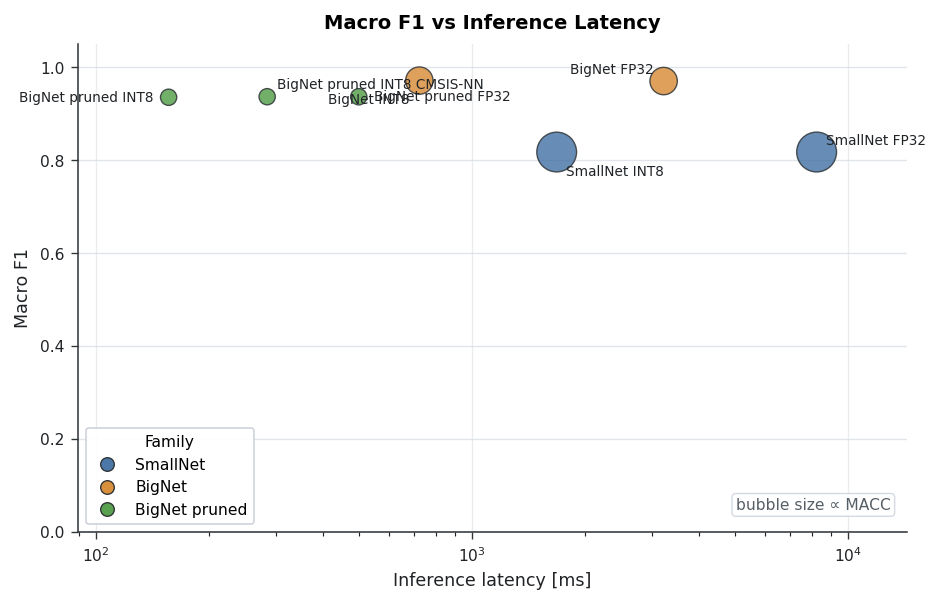

In [9]:
plot_data = df.dropna(subset=["infer_ms_mean", "macro_f1", "macc"]).copy()
plot_data = plot_data[(plot_data["infer_ms_mean"] > 0) & (plot_data["macc"] > 0)].reset_index(drop=True)
plot_data["marker_size"] = scale_marker_sizes(plot_data["macc"])

fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)

for family in family_order:
    family_data = plot_data[plot_data["family"] == family]
    if family_data.empty:
        continue
    ax.scatter(
        family_data["infer_ms_mean"],
        family_data["macro_f1"],
        s=family_data["marker_size"],
        color=FAMILY_COLORS.get(family, FAMILY_COLORS["unknown"]),
        alpha=0.85,
        edgecolor=EDGE_COLOR,
        linewidth=0.7,
    )

annotate_points(ax, plot_data, "infer_ms_mean", "macro_f1")
ax.set_title("Macro F1 vs Inference Latency", pad=8)
ax.set_xlabel("Inference latency [ms]")
ax.set_ylabel("Macro F1")
ax.set_xscale("log")
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.margins(x=0.14, y=0.08)

apply_common_axis_style(ax)
ax.grid(True, which="major", axis="x", color=GRID_COLOR, linewidth=0.7, alpha=0.55)
ax.grid(False, which="minor", axis="x")
family_legend(ax, plot_data, loc="lower left")
bubble_note(ax, "bubble size ∝ MACC")

save_figure(fig, "macro_f1_vs_inference_latency")
plt.show()


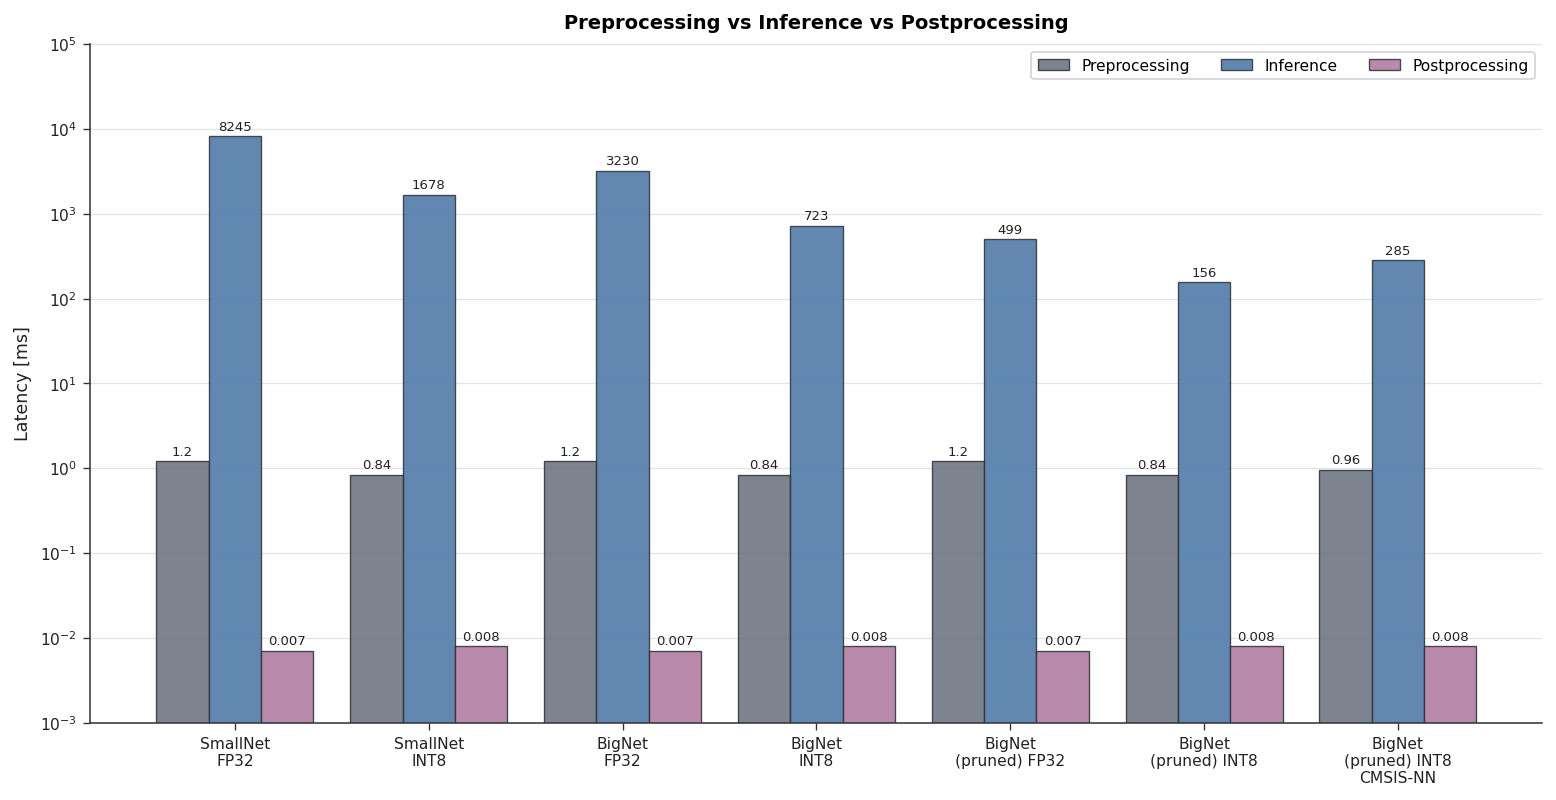

In [10]:
latency_columns = ["pre_ms_mean", "infer_ms_mean", "post_ms_mean"]
# Same model set and order as the memory-footprint plot (cell above).
plot_data = df.dropna(subset=["ram_KB", "flash_KB"]).copy().reset_index(drop=True)
has_latency = (
    plot_data[latency_columns].notna().all(axis=1)
    & plot_data[latency_columns].gt(0).all(axis=1)
)

fig, ax = plt.subplots(figsize=(11.0, 5.6), constrained_layout=True)
x_positions = np.arange(len(plot_data))
width = 0.27
series = [
    ("Preprocessing", "pre_ms_mean"),
    ("Inference", "infer_ms_mean"),
    ("Postprocessing", "post_ms_mean"),
]

ax.set_yscale("log")
measured = plot_data.loc[has_latency, latency_columns].to_numpy(dtype=float)
y_min = 10 ** np.floor(np.log10(np.nanmin(measured) * 0.8))
y_max = 10 ** np.ceil(np.log10(np.nanmax(measured) * 1.5))
ax.set_ylim(y_min, y_max)


def fmt_latency(value):
    if value >= 100:
        return f"{value:.0f}"
    if value >= 1:
        return f"{value:.2g}"
    return f"{value:.3g}"


for series_idx, (label, column) in enumerate(series):
    heights = plot_data[column].where(has_latency)
    bars = ax.bar(
        x_positions + (series_idx - 1) * width,
        heights,
        width=width,
        color=LATENCY_COLORS[label],
        edgecolor=EDGE_COLOR,
        linewidth=0.7,
        alpha=0.88,
        label=label,
    )
    add_value_labels(ax, bars, fmt=fmt_latency, fontsize=6.8, rotation=0)

# Safety net: flag any model in the set that has no on-MCU latency measurement.
for idx in x_positions[~has_latency.to_numpy()]:
    ax.text(
        idx,
        np.sqrt(y_min * y_max),
        "not measured\non MCU",
        ha="center",
        va="center",
        fontsize=7.5,
        style="italic",
        color=MUTED_TEXT_COLOR,
    )

ax.set_title("Preprocessing vs Inference vs Postprocessing", pad=8)
ax.set_ylabel("Latency [ms]")
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["axis_label"], rotation=0, ha="center")

apply_common_axis_style(ax)
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(NullLocator())
ax.grid(True, which="major", axis="y", color=GRID_COLOR, linewidth=0.7, alpha=0.75)
ax.grid(False, which="minor", axis="y")

legend = ax.legend(loc="upper right", frameon=True, ncol=3)
style_legend(legend)

save_figure(fig, "latency_pre_infer_post")
plt.show()


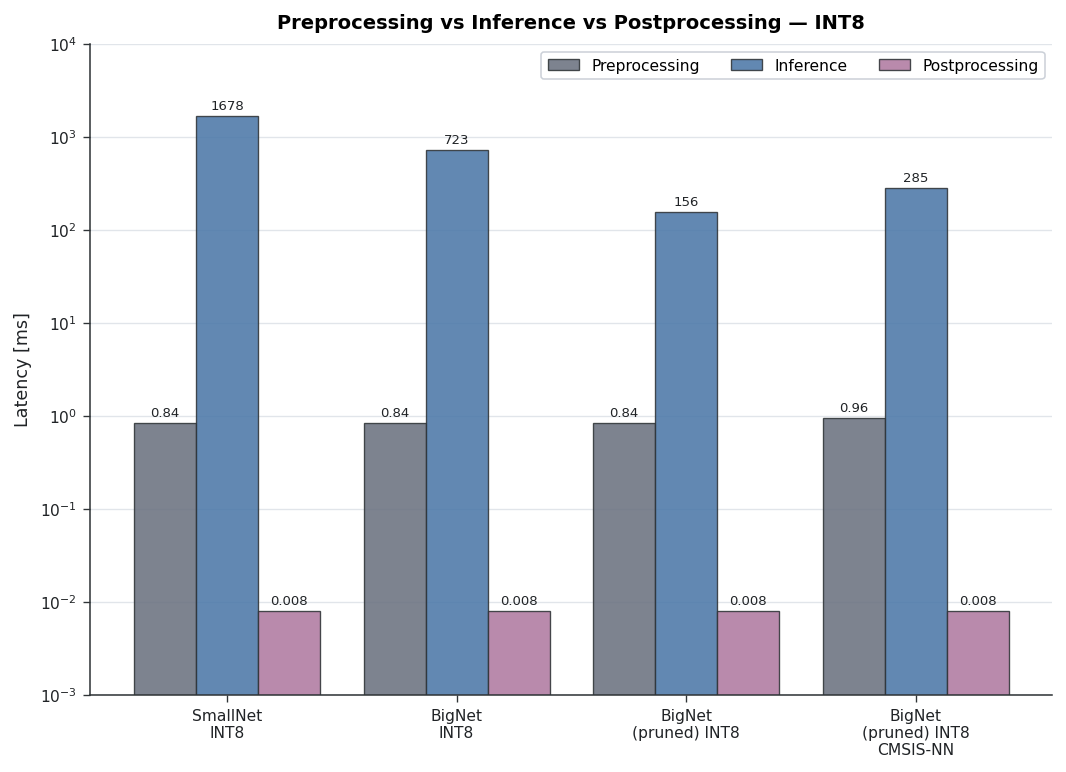

In [11]:
# Same latency plot, but restricted to the INT8 deployments (incl. the CMSIS-NN build).
latency_columns = ["pre_ms_mean", "infer_ms_mean", "post_ms_mean"]
plot_data = (
    df[df["variant"].isin(["int8", "int8_cmsisnn"])]
    .dropna(subset=["ram_KB", "flash_KB"])
    .reset_index(drop=True)
)
has_latency = (
    plot_data[latency_columns].notna().all(axis=1)
    & plot_data[latency_columns].gt(0).all(axis=1)
)

fig, ax = plt.subplots(figsize=(7.5, 5.4), constrained_layout=True)
x_positions = np.arange(len(plot_data))
width = 0.27
series = [
    ("Preprocessing", "pre_ms_mean"),
    ("Inference", "infer_ms_mean"),
    ("Postprocessing", "post_ms_mean"),
]

ax.set_yscale("log")
measured = plot_data.loc[has_latency, latency_columns].to_numpy(dtype=float)
y_min = 10 ** np.floor(np.log10(np.nanmin(measured) * 0.8))
y_max = 10 ** np.ceil(np.log10(np.nanmax(measured) * 1.5))
ax.set_ylim(y_min, y_max)


def fmt_latency(value):
    if value >= 100:
        return f"{value:.0f}"
    if value >= 1:
        return f"{value:.2g}"
    return f"{value:.3g}"


for series_idx, (label, column) in enumerate(series):
    heights = plot_data[column].where(has_latency)
    bars = ax.bar(
        x_positions + (series_idx - 1) * width,
        heights,
        width=width,
        color=LATENCY_COLORS[label],
        edgecolor=EDGE_COLOR,
        linewidth=0.7,
        alpha=0.88,
        label=label,
    )
    add_value_labels(ax, bars, fmt=fmt_latency, fontsize=6.8, rotation=0)

for idx in x_positions[~has_latency.to_numpy()]:
    ax.text(
        idx,
        np.sqrt(y_min * y_max),
        "not measured\non MCU",
        ha="center",
        va="center",
        fontsize=7.5,
        style="italic",
        color=MUTED_TEXT_COLOR,
    )

ax.set_title("Preprocessing vs Inference vs Postprocessing — INT8", pad=8)
ax.set_ylabel("Latency [ms]")
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["axis_label"], rotation=0, ha="center")

apply_common_axis_style(ax)
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(NullLocator())
ax.grid(True, which="major", axis="y", color=GRID_COLOR, linewidth=0.7, alpha=0.75)
ax.grid(False, which="minor", axis="y")

legend = ax.legend(loc="upper right", frameon=True, ncol=3)
style_legend(legend)

save_figure(fig, "latency_pre_infer_post_int8")
plt.show()


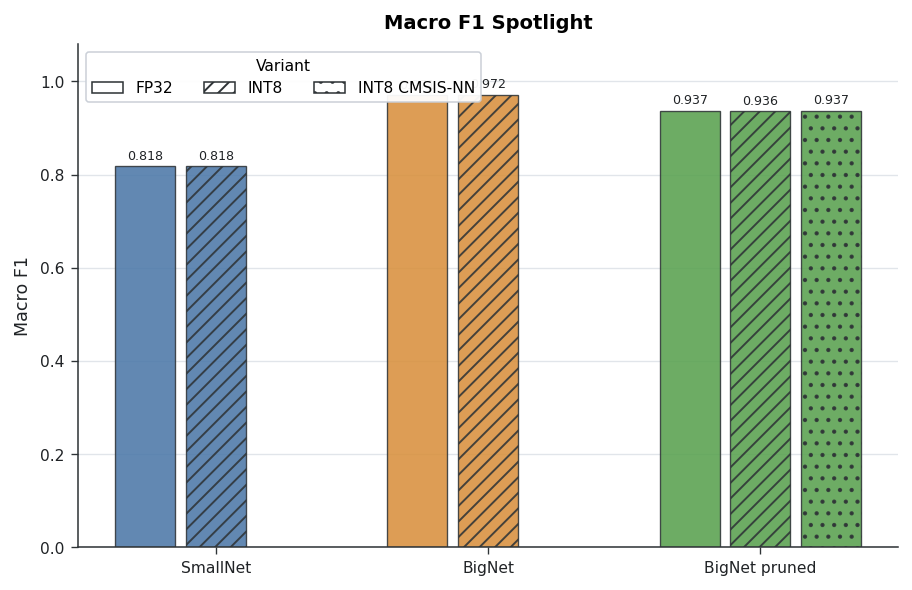

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 4.1), constrained_layout=True)
grouped_family_variant_plot(ax, "macro_f1", "Macro F1 Spotlight", "Macro F1")

save_figure(fig, "macro_f1_spotlight")
plt.show()


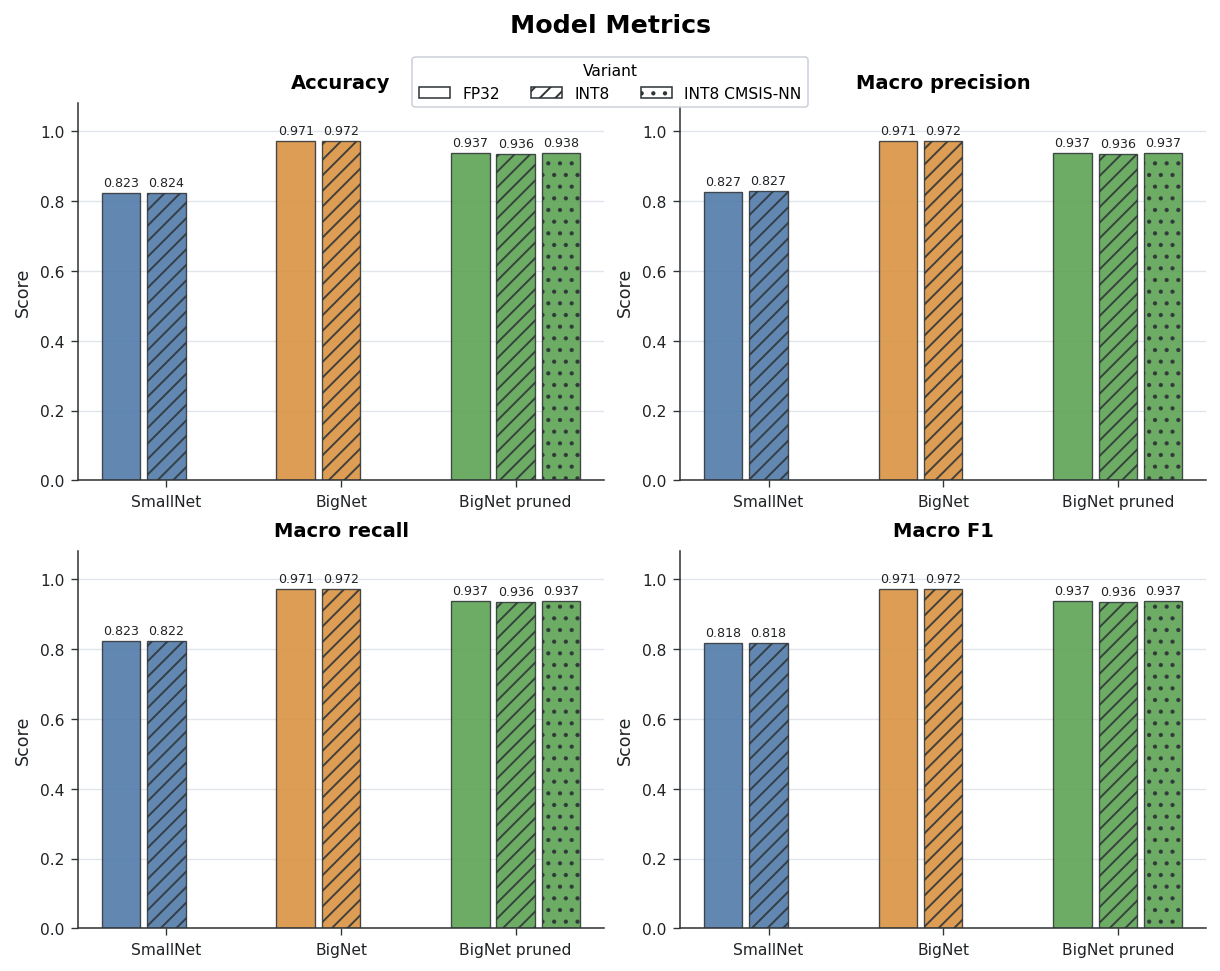

In [13]:
quality_metrics = [
    ("accuracy", "Accuracy"),
    ("macro_precision", "Macro precision"),
    ("macro_recall", "Macro recall"),
    ("macro_f1", "Macro F1"),
]

fig, axes = plt.subplots(2, 2, figsize=(8.6, 6.4), constrained_layout=True)
for ax, (metric, title) in zip(axes.flat, quality_metrics):
    grouped_family_variant_plot(ax, metric, title, "Score")
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

metric_columns = [metric for metric, _ in quality_metrics]
quality_data = df.dropna(subset=metric_columns, how="all")
available_variants = [variant for variant in variant_order if variant in set(quality_data["variant"])]
shared_legend = fig.legend(
    handles=make_variant_handles(available_variants),
    title="Variant",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=max(1, len(available_variants)),
    frameon=True,
)
style_legend(shared_legend)
fig.suptitle("Model Metrics", fontsize=13, fontweight="semibold", y=1.06)

save_figure(fig, "classification_quality_2x2")
plt.show()


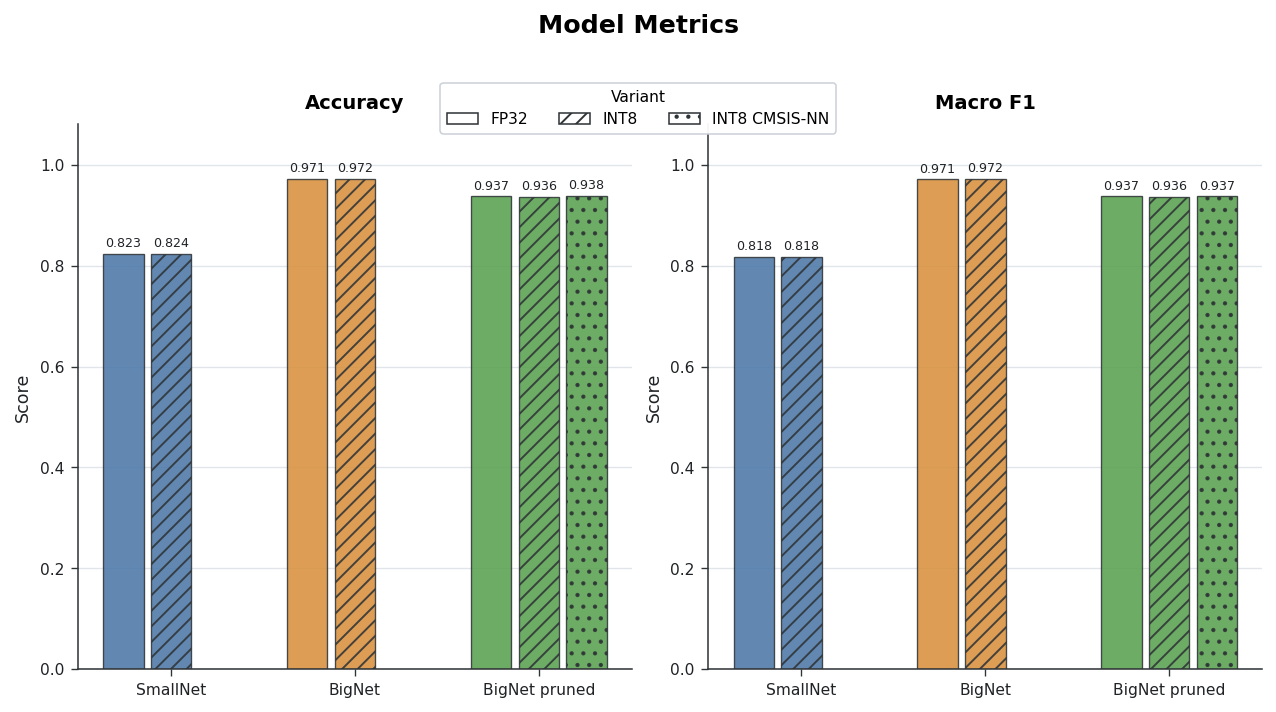

In [14]:
# Headline metrics in the classification_quality_2x2 style, but 1x2: Accuracy + Macro-F1.
# grouped_family_variant_plot reads df[metric] directly from the CSV, so values are exact.
quality_metrics = [
    ("accuracy", "Accuracy"),
    ("macro_f1", "Macro F1"),
]

fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.4), constrained_layout=True)
for ax, (metric, title) in zip(axes, quality_metrics):
    grouped_family_variant_plot(ax, metric, title, "Score")
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

metric_columns = [metric for metric, _ in quality_metrics]
quality_data = df.dropna(subset=metric_columns, how="all")
available_variants = [variant for variant in variant_order if variant in set(quality_data["variant"])]
shared_legend = fig.legend(
    handles=make_variant_handles(available_variants),
    title="Variant",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=max(1, len(available_variants)),
    frameon=True,
)
style_legend(shared_legend)
fig.suptitle("Model Metrics", fontsize=13, fontweight="semibold", y=1.12)

save_figure(fig, "metrics_accuracy_f1")
plt.show()


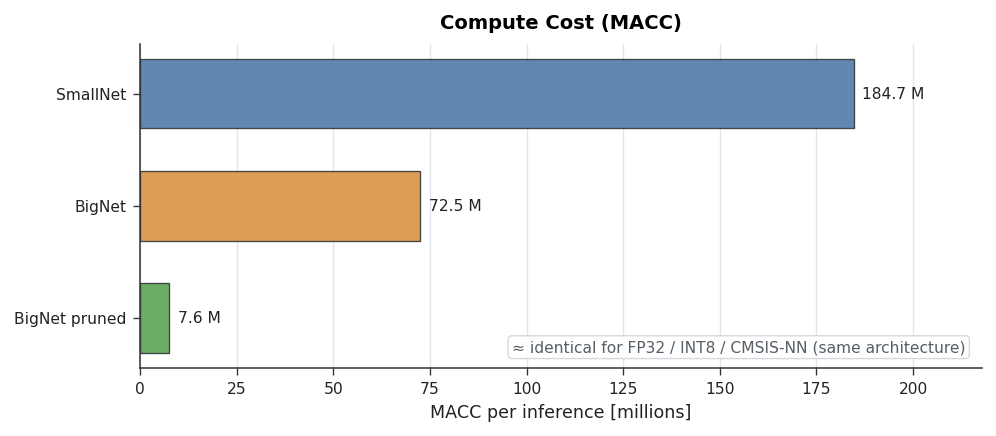

In [15]:
# MACC (multiply-accumulates per inference) is an *architectural* property: it is fixed by the
# network topology and is essentially identical for the FP32 / INT8 / CMSIS-NN variants of the
# same network. It is therefore best shown as a fact in the model-explanation section rather than
# as a per-variant result. One representative bar per family (taken from the FP32 row).
macc_by_family = []
for family in family_order:
    rows = df[(df["family"] == family) & df["macc"].notna()]
    if rows.empty:
        continue
    macc_by_family.append((family, float(rows["macc"].iloc[0])))

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
y_positions = np.arange(len(macc_by_family))
macc_millions = [value / 1e6 for _, value in macc_by_family]
colors = [FAMILY_COLORS.get(family, FAMILY_COLORS["unknown"]) for family, _ in macc_by_family]

bars = ax.barh(
    y_positions,
    macc_millions,
    color=colors,
    edgecolor=EDGE_COLOR,
    linewidth=0.7,
    alpha=0.88,
    height=0.62,
)
ax.invert_yaxis()
ax.set_yticks(y_positions)
ax.set_yticklabels([FAMILY_DISPLAY.get(family, family) for family, _ in macc_by_family])
ax.set_xlabel("MACC per inference [millions]")
ax.set_title("Compute Cost (MACC)", pad=8)
ax.set_xlim(0, max(macc_millions) * 1.18)

apply_common_axis_style(ax)
ax.grid(False, which="both", axis="y")
ax.grid(True, which="major", axis="x", color=GRID_COLOR, linewidth=0.7, alpha=0.75)

for bar, value in zip(bars, macc_millions):
    ax.text(
        bar.get_width() + max(macc_millions) * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.1f} M",
        ha="left",
        va="center",
        fontsize=8,
        color=TEXT_COLOR,
    )

bubble_note(ax, "≈ identical for FP32 / INT8 / CMSIS-NN (same architecture)")

save_figure(fig, "compute_cost_macc")
plt.show()


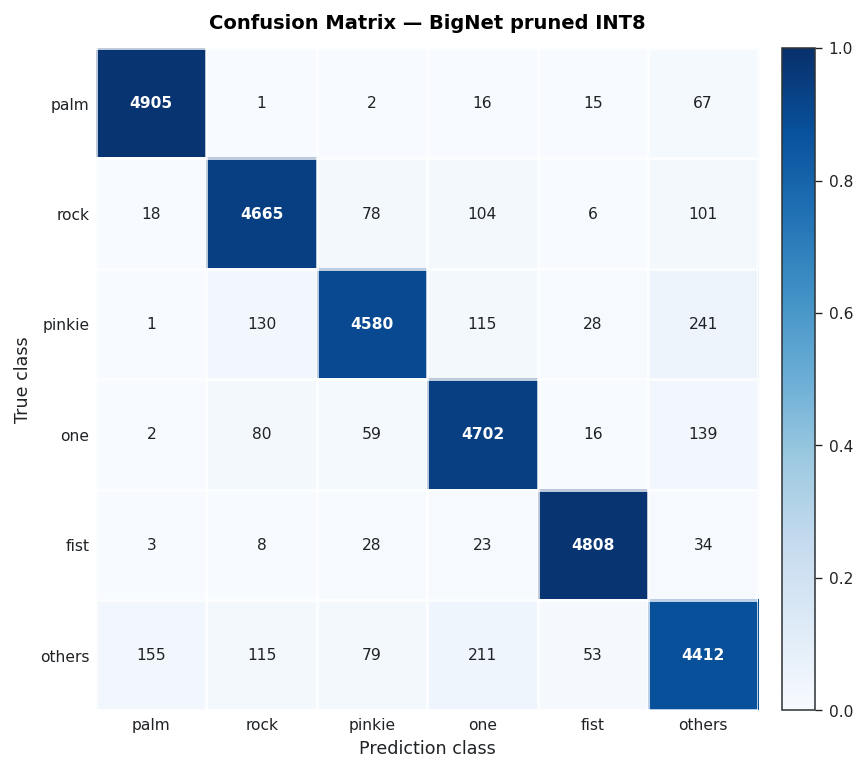

In [16]:
# Confusion matrix for the deployed model (BigNet pruned INT8), blue colour scheme.
# Colour encodes the row-normalised fraction (recall on the diagonal); cells show raw counts.
CM_MODEL_TITLE = "BigNet pruned INT8"

cm_df = pd.read_csv(BASE_DIR / "confusion_matrix_bignet_pruned_int8.csv", index_col=0)
classes = list(cm_df.columns)
counts = cm_df.to_numpy(dtype=float)
frac = counts / counts.sum(axis=1, keepdims=True)
n_classes = len(classes)

fig, ax = plt.subplots(figsize=(6.4, 5.4), constrained_layout=True)
im = ax.imshow(frac, cmap="Blues", vmin=0.0, vmax=1.0, aspect="equal")

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Prediction class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion Matrix — {CM_MODEL_TITLE}", pad=10)

# White separators between cells; hide ticks and frame for a clean look.
ax.set_xticks(np.arange(-0.5, n_classes, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_classes, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_classes):
    for j in range(n_classes):
        ax.text(
            j,
            i,
            f"{int(counts[i, j])}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if frac[i, j] > 0.5 else TEXT_COLOR,
            fontweight="semibold" if i == j else "normal",
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.outline.set_linewidth(0.8)
cbar.outline.set_edgecolor(EDGE_COLOR)

save_figure(fig, "confusion_matrix_bignet_pruned_int8")
plt.show()


In [17]:
created_files = sorted(PLOT_DIR.glob("*"))
print(f"Output directory: {PLOT_DIR.resolve()}")
for path in created_files:
    print(f"- {path.name}")


Output directory: /Users/lukas.amiet/Documents/CODE/MLonMCU_proj/presentation/classifier/plots/model_comparison/v2
- accuracy_vs_flash_footprint.pdf
- accuracy_vs_flash_footprint.png
- accuracy_vs_flash_footprint.svg
- accuracy_vs_inference_latency.pdf
- accuracy_vs_inference_latency.png
- accuracy_vs_inference_latency.svg
- classification_quality_2x2.pdf
- classification_quality_2x2.png
- classification_quality_2x2.svg
- compute_cost_macc.pdf
- compute_cost_macc.png
- compute_cost_macc.svg
- confusion_matrix_bignet_pruned_int8.pdf
- confusion_matrix_bignet_pruned_int8.png
- confusion_matrix_bignet_pruned_int8.svg
- latency_pre_infer_post.pdf
- latency_pre_infer_post.png
- latency_pre_infer_post.svg
- latency_pre_infer_post_int8.pdf
- latency_pre_infer_post_int8.png
- latency_pre_infer_post_int8.svg
- macro_f1_per_inference_ms.pdf
- macro_f1_per_inference_ms.png
- macro_f1_per_inference_ms.svg
- macro_f1_spotlight.pdf
- macro_f1_spotlight.png
- macro_f1_spotlight.svg
- macro_f1_vs_infe